<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Aula_2_TAREFA_Valores_faltantes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importanto bibliotecas principais**

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation

#**Carregando dados no colab**

Dataset: https://www.kaggle.com/code/residentmario/simple-techniques-for-missing-data-imputation/input

In [10]:
#Subindo dados para o colab
from google.colab import files
uploaded_files = files.upload()

Saving recipeData.csv to recipeData (1).csv


In [11]:
df = pd.read_csv('recipeData.csv', encoding='latin-1') #salvando o dataset em um dataframe
df.head() #visualizando cabeçalho do dataset

,BeerID,Name,URL,Style,StyleID,Size(L),OG,FG,ABV,IBU,...,BoilGravity,Efficiency,MashThickness,SugarScale,BrewMethod,PitchRate,PrimaryTemp,PrimingMethod,PrimingAmount,UserId
0,1,Vanilla Cream Ale,/homebrew/recipe/view/1633/vanilla-cream-ale,Cream Ale,45,21.77,1.055,1.013,5.48,17.65,...,1.038,70.0,NaN,Specific Gravity,All Grain,NaN,17.78,corn sugar,4.5 oz,116.0
1,2,Southern Tier Pumking clone,/homebrew/recipe/view/16367/southern-tier-pumk...,Holiday/Winter Special Spiced Beer,85,20.82,1.083,1.021,8.16,60.65,...,1.070,70.0,NaN,Specific Gravity,All Grain,NaN,NaN,NaN,NaN,955.0
2,3,Zombie Dust Clone - EXTRACT,/homebrew/recipe/view/5920/zombie-dust-clone-e...,American IPA,7,18.93,1.063,1.018,5.91,59.25,...,NaN,70.0,NaN,Specific Gravity,extract,NaN,NaN,NaN,NaN,NaN
3,4,Zombie Dust Clone - ALL GRAIN,/homebrew/recipe/view/5916/zombie-dust-clone-a...,American IPA,7,22.71,1.061,1.017,5.80,54.48,...,NaN,70.0,NaN,Specific Gravity,All Grain,NaN,NaN,NaN,NaN,NaN
4,5,Bakke Brygg Belgisk Blonde 50 l,/homebrew/recipe/view/89534/bakke-brygg-belgis...,Belgian Blond Ale,20,50.00,1.060,1.010,6.48,17.84,...,1.050,72.0,NaN,Specific Gravity,All Grain,NaN,19.00,Sukkerlake,6-7 g sukker/l,18325.0


#**Verificando dados vazios**

In [43]:
# Verificando dados
print ("Tabela 1 - Verificação de dados")
print(df.info())
print("\n") #paragráfo entre os resultados

# Verificando se há algum valor vazio
print ("Tabela 2 - Verificação de dados vazios")
print(df.isna().any())
print("\n")

# Verificando quantidade de dados vazios
print ("Tabela 3 - Verificação de quantidade de dados vazios")
print(df.isna().sum())
print("\n")

Tabela 1 - Verificação de dados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73861 entries, 0 to 73860
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BeerID         73861 non-null  int64  
 1   Name           73859 non-null  object 
 2   URL            73861 non-null  object 
 3   Style          73265 non-null  object 
 4   StyleID        73861 non-null  int64  
 5   Size(L)        73861 non-null  float64
 6   OG             73861 non-null  float64
 7   FG             73861 non-null  float64
 8   ABV            73861 non-null  float64
 9   IBU            73861 non-null  float64
 10  Color          73861 non-null  float64
 11  BoilSize       73861 non-null  float64
 12  BoilTime       73861 non-null  int64  
 13  BoilGravity    70871 non-null  float64
 14  Efficiency     73861 non-null  float64
 15  MashThickness  43997 non-null  float64
 16  SugarScale     73861 non-null  object 
 17  BrewMethod     738

**Visualizando dados vázios gráficamente**

<Axes: >

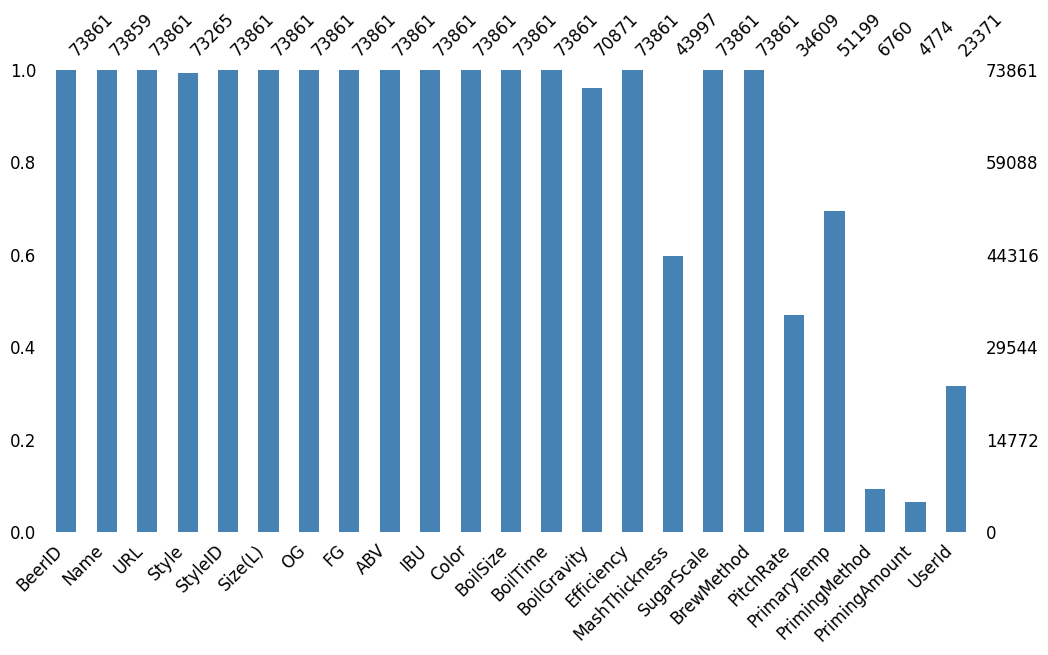

In [44]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df, figsize=(12, 6), fontsize=12, color='steelblue')

#Desenvolvimento da atividade:

##Selecionar:


*  uma coluna numérica de sua escolha;
*  uma coluna categórica de sua escolha.

# Coluna Numérica: PrimaryTemp (temperatura de fermentação)
# Coluna Categórica: Style (tipo de cerveja)

## Para a variável Numérica:

média do grupo;

função de probabilidade;

spline;

KNN;

MICE.

###Média do Grupo

In [62]:
df_m1 = df.copy()
df_m1['PrimaryTemp'] = df.groupby('Style')['PrimaryTemp'].transform(
    lambda x: x.fillna(x.mean())
)
df_m1['PrimaryTemp'] = df_m1['PrimaryTemp'].fillna(df['PrimaryTemp'].mean())

# Verificação
print(f"Missings antes:  {df['PrimaryTemp'].isna().sum()}")
print(f"Missings depois: {df_m1['PrimaryTemp'].isna().sum()}")
print(f"\nDistribuição original → média: {df['PrimaryTemp'].mean():.2f}, std: {df['PrimaryTemp'].std():.2f}")
print(f"Distribuição imputada → média: {df_m1['PrimaryTemp'].mean():.2f}, std: {df_knn['PrimaryTemp'].std():.2f}")

Missings antes:  22662
Missings depois: 0

Distribuição original → média: 19.18, std: 4.22
Distribuição imputada → média: 19.20, std: 3.71


<Axes: >

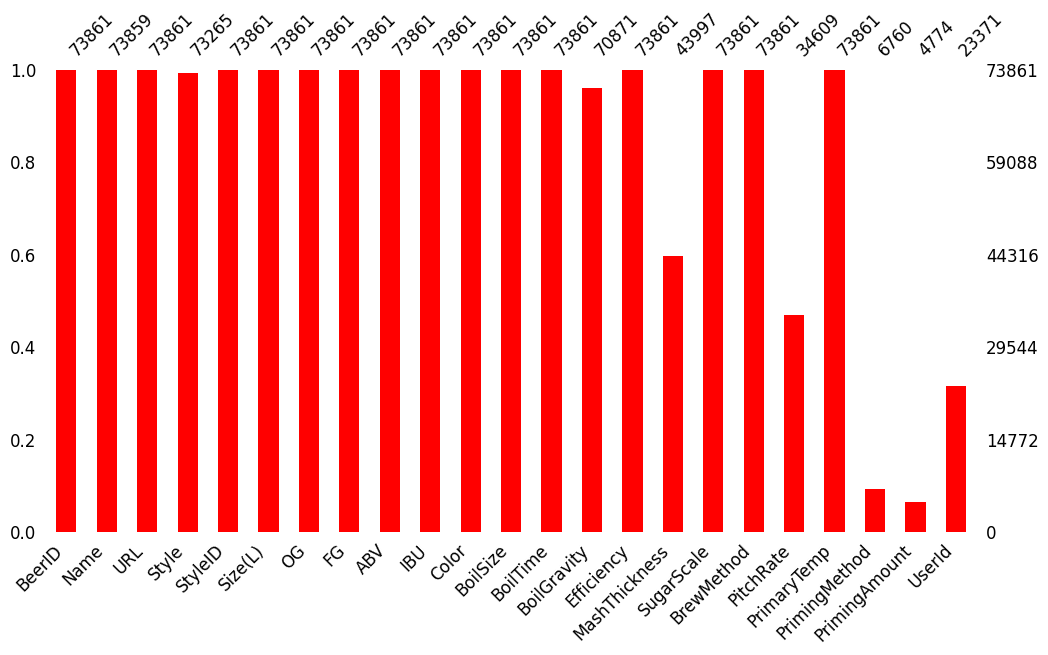

In [49]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_m1, figsize=(12, 6), fontsize=12, color='red')

##Função de Probabilidade;

In [50]:
from scipy import stats
import numpy as np

# Copiar o DataFrame original
df_prob = df.copy()

# Coluna a ser imputada
column_to_impute = 'PrimaryTemp'

# Estimativa dos parâmetros da distribuição normal
mean = df_prob[column_to_impute].mean()
std_dev = df_prob[column_to_impute].std()

# Identificar os valores ausentes
missing_mask = df_prob[column_to_impute].isnull()

# Gerar valores simulados para preencher os dados ausentes
simulated_values = np.random.normal(loc=mean, scale=std_dev, size=missing_mask.sum())

# Preencher os valores ausentes com os valores simulados
df_prob.loc[missing_mask, column_to_impute] = simulated_values

# Verificação
print(f"Missings antes:  {df[column_to_impute].isna().sum()}")
print(f"Missings depois: {df_prob[column_to_impute].isna().sum()}")
print(f"\nDistribuição original → média: {mean:.2f}, std: {std_dev:.2f}")
print(f"Distribuição imputada → média: {df_prob[column_to_impute].mean():.2f}, std: {df_prob[column_to_impute].std():.2f}")

Missings antes:  22662
Missings depois: 0

Distribuição original → média: 19.18, std: 4.22
Distribuição imputada → média: 19.17, std: 4.23


<Axes: >

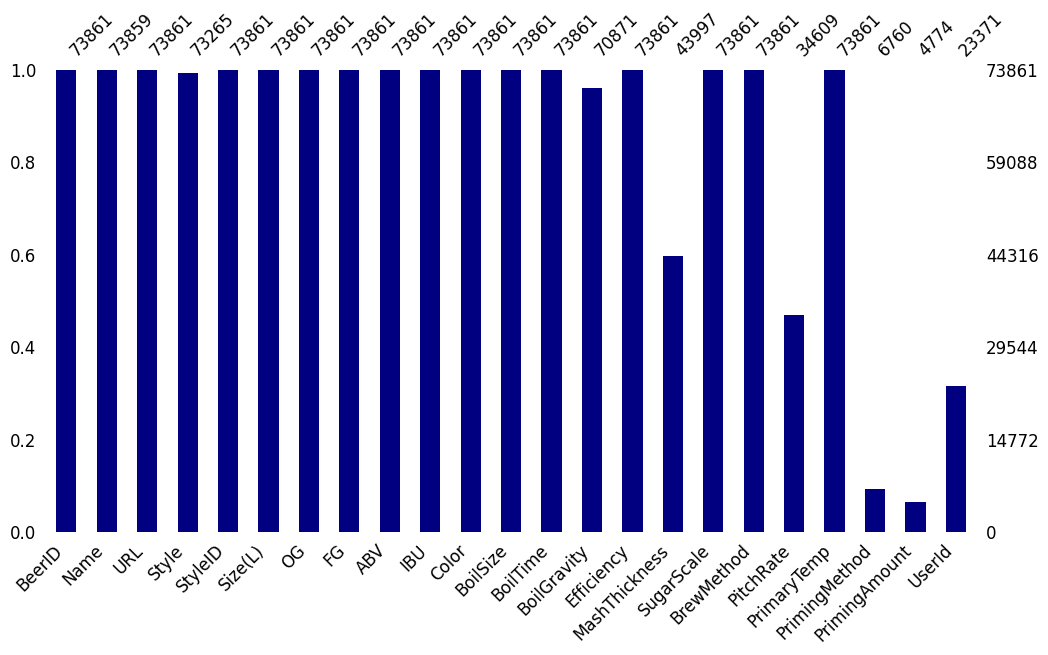

In [52]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_prob, figsize=(12, 6), fontsize=12, color='navy')

##Spline;

In [55]:
# Copiar o DataFrame original
df_spline = df.copy()

# Coluna a ser imputada
column_to_impute = 'PrimaryTemp'

# Imputação por Spline
df_spline[column_to_impute] = df_spline[column_to_impute].interpolate(method='spline', order=3)

# Verificação
print(f"Missings antes:  {df[column_to_impute].isna().sum()}")
print(f"Missings depois: {df_spline[column_to_impute].isna().sum()}")
print(f"\nDistribuição original → média: {df[column_to_impute].mean():.2f}, std: {df[column_to_impute].std():.2f}")
print(f"Distribuição imputada → média: {df_spline[column_to_impute].mean():.2f}, std: {df_spline[column_to_impute].std():.2f}")

Missings antes:  22662
Missings depois: 0

Distribuição original → média: 19.18, std: 4.22
Distribuição imputada → média: 19.19, std: 4.65


<Axes: >

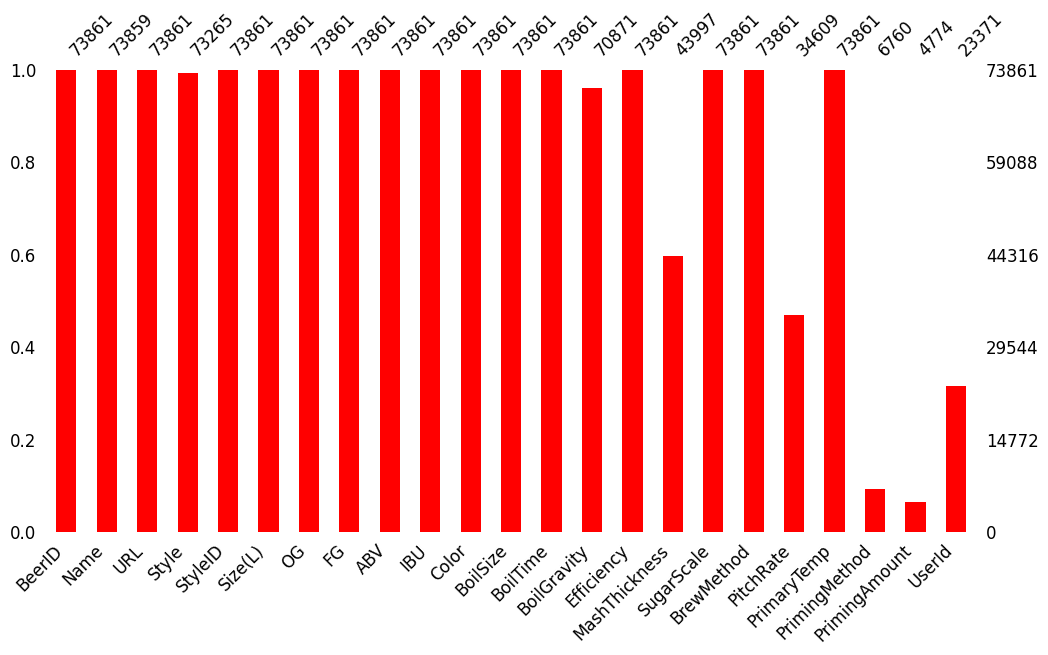

In [56]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_spline, figsize=(12, 6), fontsize=12, color='red')

⚠️ Importante: Spline assume que a ordem das linhas importa (ideal para séries temporais). No nosso dataset a ordem é arbitrária, então os valores imputados dependem dos vizinhos de índice — não dos vizinhos "lógicos". O método funciona, mas é menos adequado para esse tipo de dado.

## KNN;

In [57]:
from sklearn.impute import KNNImputer

# Copiar o DataFrame original
df_knn = df.copy()

# Colunas preditoras com maior relação lógica com PrimaryTemp
cols = ['PrimaryTemp', 'ABV', 'IBU','OG', 'FG', 'Color', 'BoilGravity']

# Imputação por KNN
imputer_knn = KNNImputer(n_neighbors=5)
df_knn[cols] = imputer_knn.fit_transform(df_knn[cols])

# Verificação
print(f"Missings antes:  {df['PrimaryTemp'].isna().sum()}")
print(f"Missings depois: {df_knn['PrimaryTemp'].isna().sum()}")
print(f"\nDistribuição original → média: {df['PrimaryTemp'].mean():.2f}, std: {df['PrimaryTemp'].std():.2f}")
print(f"Distribuição imputada → média: {df_knn['PrimaryTemp'].mean():.2f}, std: {df_knn['PrimaryTemp'].std():.2f}")

Missings antes:  22662
Missings depois: 0

Distribuição original → média: 19.18, std: 4.22
Distribuição imputada → média: 19.22, std: 3.71


<Axes: >

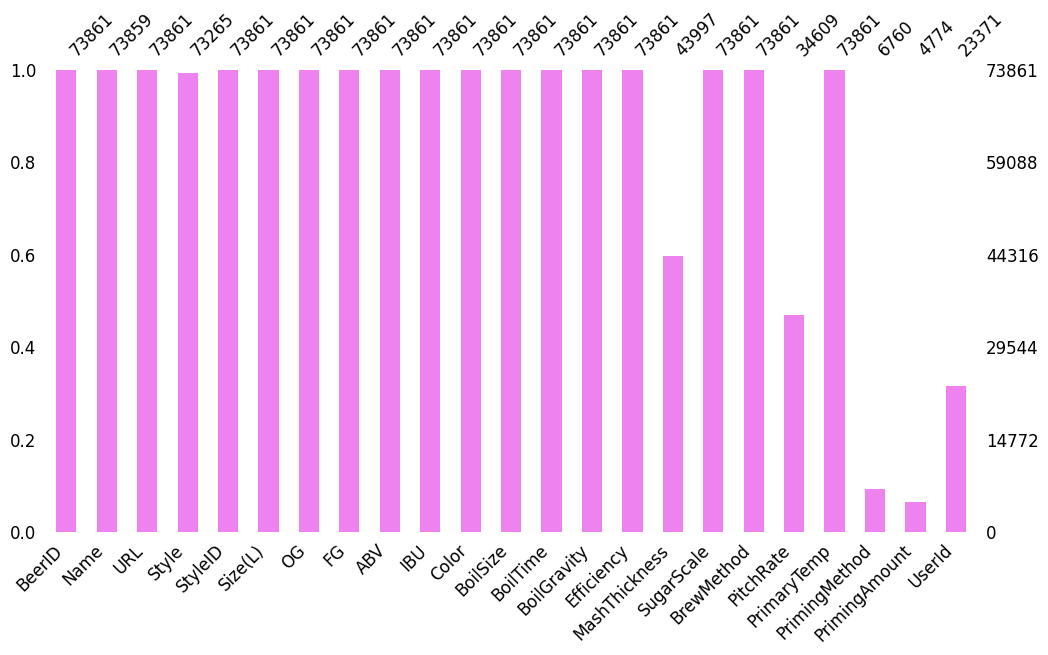

In [58]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_knn, figsize=(12, 6), fontsize=12, color='violet')

⚠️ Importante: O KNN usa distância euclidiana entre as colunas preditoras para encontrar os 5 vizinhos mais próximos e calcular a média. Por isso a escolha das colunas preditoras impacta diretamente o resultado — variáveis sem relação com PrimaryTemp podem piorar a imputação. Vale confirmar as correlações com df[cols].corr()['PrimaryTemp'] antes de rodar.

##MICE

In [59]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Copiar o DataFrame original
df_mice = df.copy()

# Colunas preditoras com maior relação lógica com PrimaryTemp
cols = ['PrimaryTemp', 'ABV', 'IBU', 'OG', 'FG', 'Color', 'BoilGravity']

# Imputação por MICE
imputer_mice = IterativeImputer(max_iter=10, random_state=42)
df_mice[cols] = imputer_mice.fit_transform(df_mice[cols])

# Verificação
print(f"Missings antes:  {df['PrimaryTemp'].isna().sum()}")
print(f"Missings depois: {df_mice['PrimaryTemp'].isna().sum()}")
print(f"\nDistribuição original → média: {df['PrimaryTemp'].mean():.2f}, std: {df['PrimaryTemp'].std():.2f}")
print(f"Distribuição imputada → média: {df_mice['PrimaryTemp'].mean():.2f}, std: {df_mice['PrimaryTemp'].std():.2f}")

Missings antes:  22662
Missings depois: 0

Distribuição original → média: 19.18, std: 4.22
Distribuição imputada → média: 19.17, std: 3.52


<Axes: >

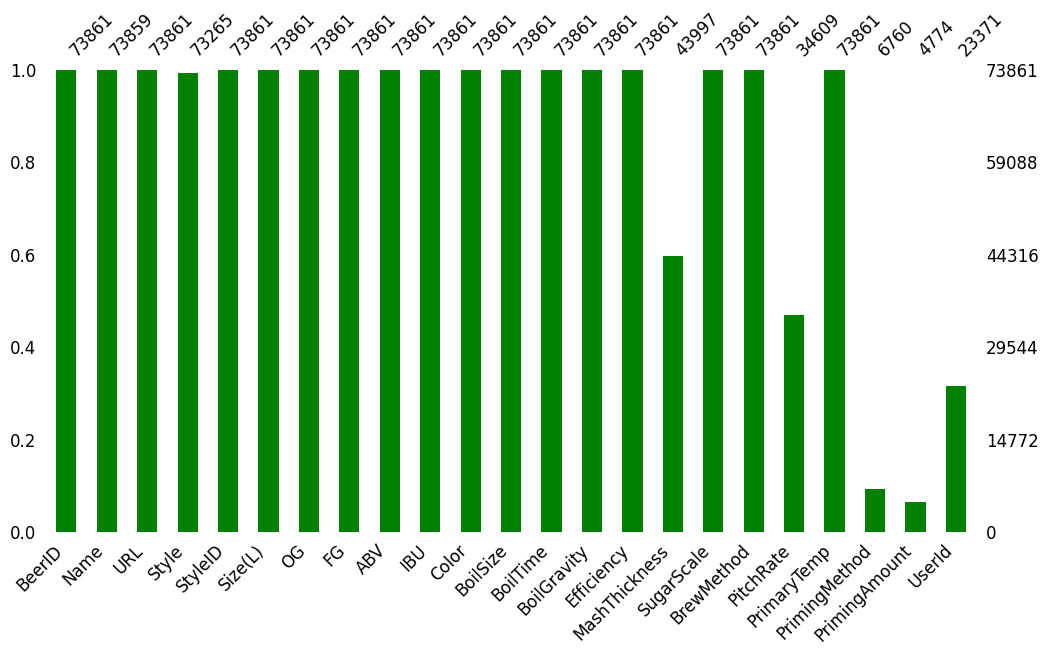

In [61]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_mice, figsize=(12, 6), fontsize=12, color='green')

#Comparação e discussão:
Função de Probabilidade foi o método que melhor preservou a distribuição original (std quase idêntico). Isso era esperado: o método amostra diretamente da distribuição estimada, então média e desvio tendem a se manter.

Média do Grupo e KNN apresentaram o mesmo std final (3.71) — ambos "suavizam" os dados ao imputar valores próximos à média, o que reduz a variabilidade. Esse é um efeito colateral conhecido: quanto mais missings, maior o achatamento da distribuição.

MICE teve a maior redução de std (-0.70), o que indica maior suavização iterativa. Apesar de ser o método mais sofisticado estatisticamente, aqui produziu a distribuição mais distante da original — possivelmente porque as colunas preditoras escolhidas têm correlação fraca com PrimaryTemp.

Spline foi o único que aumentou o std (+0.43), criando valores extremos ao interpolar entre índices distantes — reflexo direto do problema já mencionado: a ordem das linhas é arbitrária, o que distorce a interpolação.

##Histograma/KDE — ver a forma da distribuição

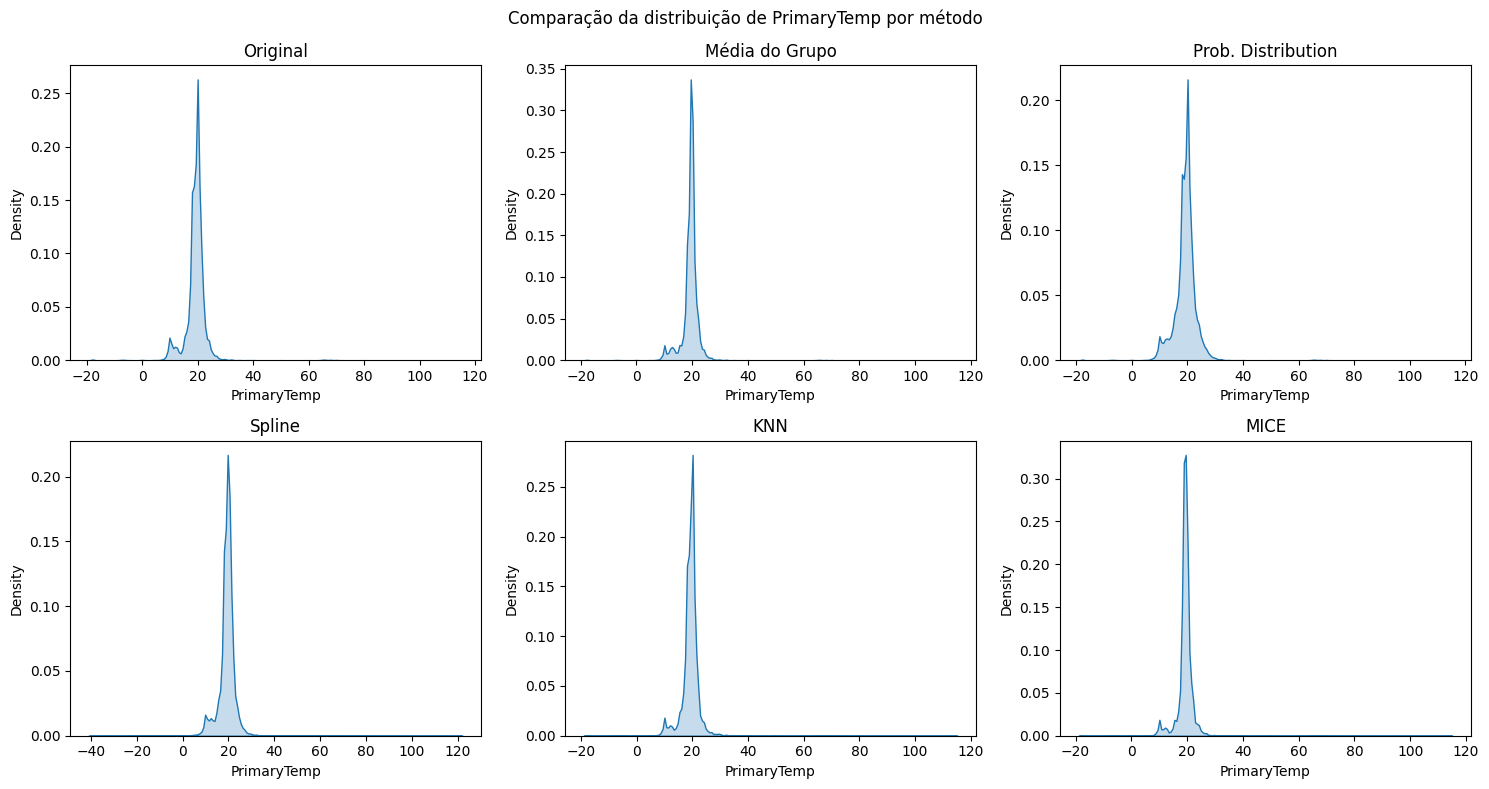

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Comparação da distribuição de PrimaryTemp por método')

datasets = {
    'Original': df['PrimaryTemp'].dropna(),
    'Média do Grupo': df_mean_group['PrimaryTemp'],
    'Prob. Distribution': df_prob['PrimaryTemp'],
    'Spline': df_spline['PrimaryTemp'],
    'KNN': df_knn['PrimaryTemp'],
    'MICE': df_mice['PrimaryTemp']
}

for ax, (nome, dados) in zip(axes.flatten(), datasets.items()):
    sns.kdeplot(dados, ax=ax, fill=True)
    ax.set_title(nome)
    ax.set_xlabel('PrimaryTemp')

plt.tight_layout()
plt.show()

KDE — Forma da distribuição

Todos os métodos preservaram o pico principal em ~20°C, mas com diferenças na "cauda" esquerda:

Original e Prob. Distribution → caudas mais largas e naturais, distribuição mais fiel

Média do Grupo, KNN e MICE → pico mais estreito e alto (densidade maior no centro) — confirmando o achatamento da variabilidade já observado no std

Spline → única com extensão para valores negativos (até -39°C), claramente artificial

##Boxplot — ver mediana, quartis e outliers

/tmp/ipykernel_8499/1821766946.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_plot, labels=datasets.keys())


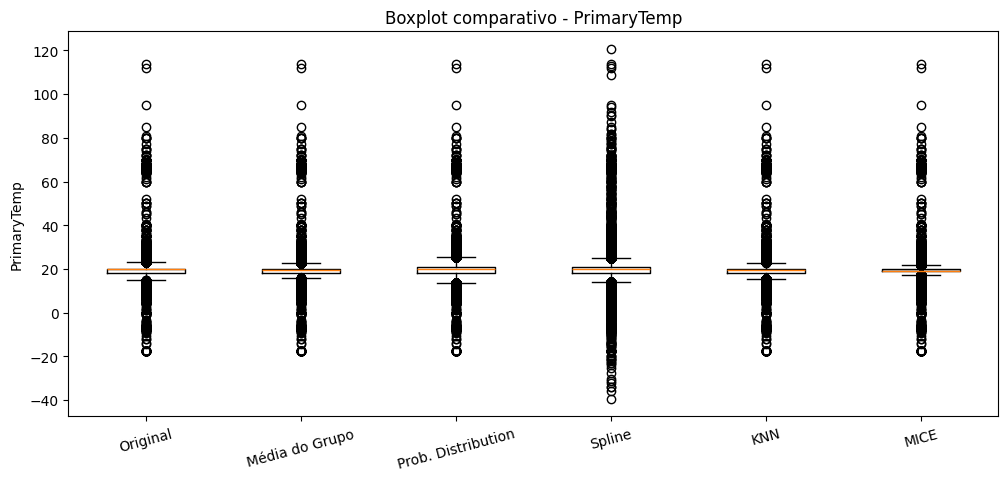

In [64]:
fig, ax = plt.subplots(figsize=(12, 5))

data_plot = [d.dropna() for d in datasets.values()]
ax.boxplot(data_plot, labels=datasets.keys())
ax.set_title('Boxplot comparativo - PrimaryTemp')
ax.set_ylabel('PrimaryTemp')
plt.xticks(rotation=15)
plt.show()

##Boxplot — Mediana e outliers

•	A mediana (linha laranja) ficou estável em ~ 20°C em todos os métodos ✅

•	Spline é o único com outlier negativo extremo (-39°C) — valor impossível para temperatura de fermentação ❌

•	Prob. Distribution gerou outliers negativos leves (~-20°C), presentes também no original — comportamento esperado por amostrar da distribuição normal


##Tabela — Quartis revelam suavização

In [65]:
import pandas as pd

stats_df = pd.DataFrame({
    nome: dados.describe().loc[['mean','std','min','25%','50%','75%','max']]
    for nome, dados in datasets.items()
})

print(stats_df.round(2))

      Original  Média do Grupo  Prob. Distribution  Spline     KNN    MICE
mean     19.18           19.20               19.17   19.19   19.22   19.17
std       4.22            3.64                4.23    4.65    3.71    3.52
min     -17.78          -17.78              -17.78  -39.54  -17.78  -17.78
25%      18.00           18.33               18.00   18.00   18.33   18.81
50%      20.00           19.57               19.76   19.75   19.58   19.19
75%      20.00           20.00               21.00   20.72   20.15   20.00
max     114.00          114.00              114.00  120.66  114.00  114.00


MICE comprimiu o Q1 de 18.00 para 18.81 — maior suavização dos quartis, reduzindo a amplitude interquartil

Spline extrapolou min e max para além dos limites reais do dataset — problemático para modelos

Prob. Distribution foi o único que manteve Q1 e min idênticos ao original

#Impactos na análise:

Métodos que reduzem o std (Média do Grupo, KNN, MICE) podem mascarar variabilidade real — análises de dispersão, outliers e intervalos de confiança seriam afetados

O Spline poderia introduzir valores irreais de temperatura (muito altos ou baixos) que distorceriam modelos preditivos

A Função de Probabilidade é a mais segura quando o objetivo é preservar a distribuição, mas introduz aleatoriedade — rodar duas vezes dá resultados diferentes

#Método mais adequado para PrimaryTemp?

Para esse dataset: Função de Probabilidade, pela melhor preservação da distribuição. Se o objetivo fosse um modelo preditivo, o KNN com melhores preditoras seria preferível.

#Conclusão Variável Numérica:

🥇 Prob. Distribution → melhor preservação geral da distribuição

🥈 Média do Grupo → simples e estável, mas suaviza

⚠️ KNN e MICE → robustos mas comprimem a variabilidade

❌ Spline → inadequado para esse dataset, gera valores fisicamente impossíveis

##Para a Variável Categórica:

KNN;

MICE.

#KNN

In [71]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Copiar o DataFrame original
df_knn_cat = df.copy()

# Codificar a coluna Style (categórica → numérica)
le = LabelEncoder()
df_knn_cat['Style_encoded'] = le.fit_transform(df_knn_cat['Style'].astype(str))

# Marcar os NaN originais antes de codificar
missing_mask = df['Style'].isna()
df_knn_cat.loc[missing_mask, 'Style_encoded'] = np.nan

# Colunas preditoras numéricas com relação lógica com Style
cols = ['Style_encoded', 'ABV', 'IBU', 'OG', 'FG', 'Color']

# Imputação por KNN
imputer_knn_cat = KNNImputer(n_neighbors=5)
df_knn_cat[cols] = imputer_knn_cat.fit_transform(df_knn_cat[cols])

# Arredondar e decodificar de volta para categoria
df_knn_cat['Style_encoded'] = df_knn_cat['Style_encoded'].round().astype(int)
df_knn_cat['Style_knn'] = le.inverse_transform(df_knn_cat['Style_encoded'])

# Verificação
print(f"Missings antes:  {df['Style'].isna().sum()}")
print(f"Missings depois: {df_knn_cat['Style_knn'].isna().sum()}")
print(f"\nEstilos imputados (primeiros 10):")
print(df_knn_cat.loc[missing_mask, 'Style_knn'].head(10).values)

Missings antes:  596
Missings depois: 0

Estilos imputados (primeiros 10):
['Oatmeal Stout' 'German Leichtbier' 'California Common Beer'
 'American IPA' 'Baltic Porter' 'Classic Rauchbier'
 'Classic American Pilsner' 'Classic Style Smoked Beer' 'Saison'
 'Dark American Lager']


<Axes: >

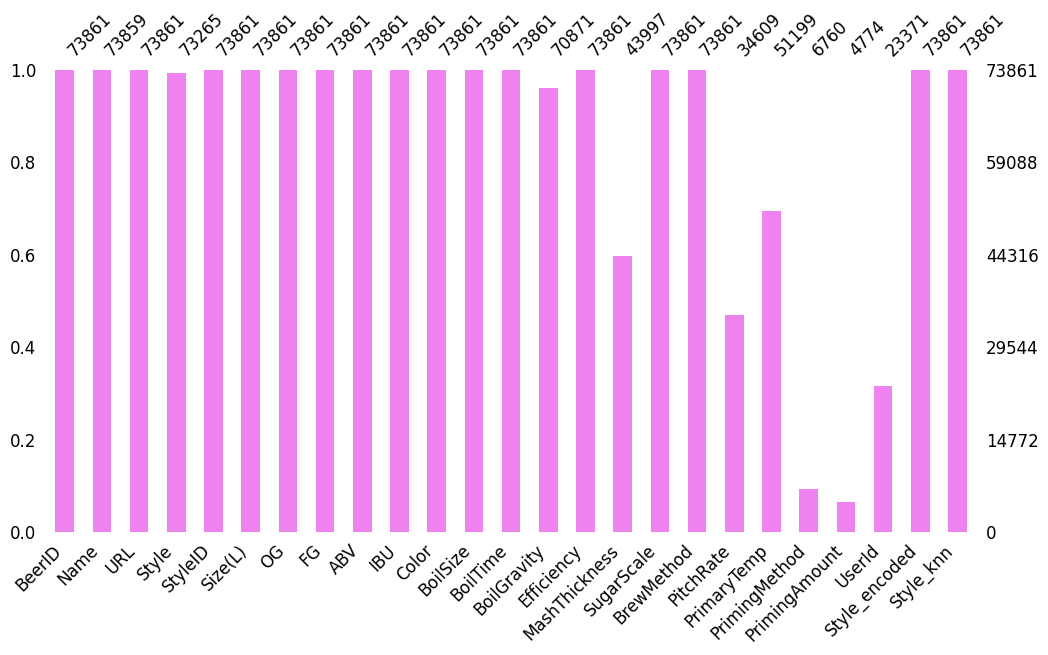

In [72]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_knn_cat, figsize=(12, 6), fontsize=12, color='violet')

⚠️ Importante: O KNN não opera nativamente em variáveis categóricas — por isso é necessário codificar o Style em números via LabelEncoder, aplicar o KNN, e depois decodificar de volta. O arredondamento é necessário pois o KNN retorna a média dos vizinhos (valor contínuo), e precisamos mapear de volta para um índice inteiro de categoria. Isso significa que o método escolhe o estilo do vizinho mais "médio" — não necessariamente o mais frequente entre os 5 vizinhos.

##MICE

In [73]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Copiar o DataFrame original
df_mice_cat = df.copy()

# Codificar a coluna Style (categórica → numérica)
le_mice = LabelEncoder()
df_mice_cat['Style_encoded'] = le_mice.fit_transform(df_mice_cat['Style'].astype(str))

# Marcar os NaN originais antes de codificar
missing_mask = df['Style'].isna()
df_mice_cat.loc[missing_mask, 'Style_encoded'] = np.nan

# Colunas preditoras numéricas com relação lógica com Style
cols = ['Style_encoded', 'ABV', 'IBU', 'OG', 'FG', 'Color']

# Imputação por MICE
imputer_mice_cat = IterativeImputer(max_iter=10, random_state=42)
df_mice_cat[cols] = imputer_mice_cat.fit_transform(df_mice_cat[cols])

# Arredondar e decodificar de volta para categoria
df_mice_cat['Style_encoded'] = df_mice_cat['Style_encoded'].round().astype(int)

# Garantir que índices estejam dentro do range válido
n_classes = len(le_mice.classes_)
df_mice_cat['Style_encoded'] = df_mice_cat['Style_encoded'].clip(0, n_classes - 1)

df_mice_cat['Style_mice'] = le_mice.inverse_transform(df_mice_cat['Style_encoded'])

# Verificação
print(f"Missings antes:  {df['Style'].isna().sum()}")
print(f"Missings depois: {df_mice_cat['Style_mice'].isna().sum()}")
print(f"\nEstilos imputados (primeiros 10):")
print(df_mice_cat.loc[missing_mask, 'Style_mice'].head(10).values)

Missings antes:  596
Missings depois: 0

Estilos imputados (primeiros 10):
['Gose' 'Dusseldorf Altbier' 'Flanders Brown Ale/Oud Bruin'
 'Czech Premium Pale Lager' 'Double IPA' 'Festbier' 'Dry Mead' 'Dry Mead'
 'French Cider' 'Dusseldorf Altbier']


<Axes: >

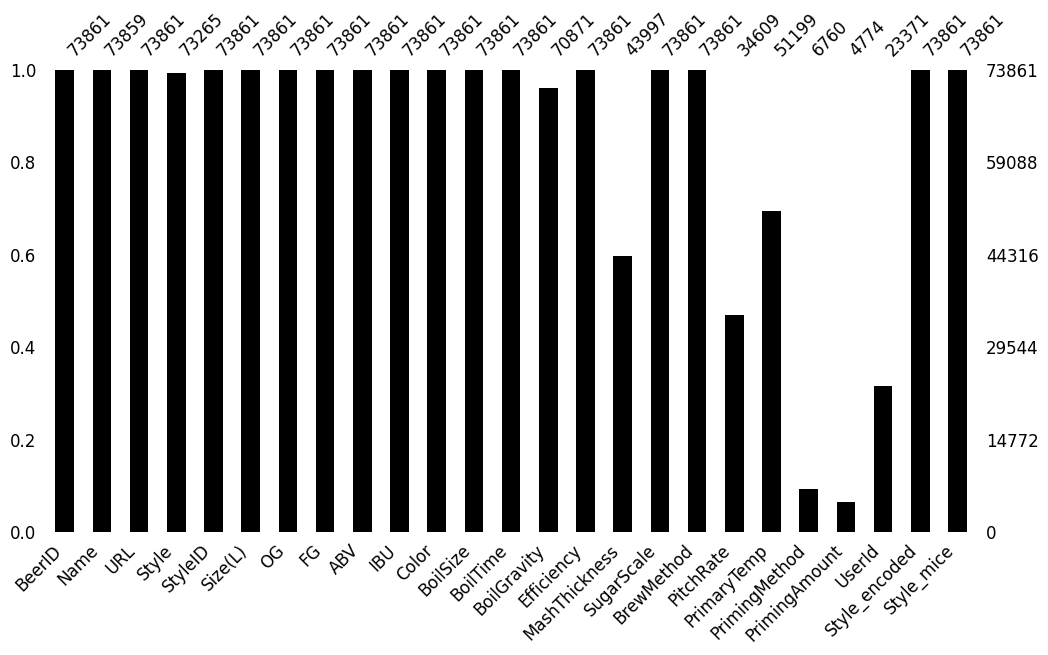

In [76]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df_mice_cat, figsize=(12, 6), fontsize=12, color='black')

⚠️ Importante: O MICE pode gerar valores fora do range dos índices válidos ao interpolar iterativamente — por isso o .clip(0, n_classes - 1) é essencial para evitar erros na decodificação. Assim como no KNN, o processo de codificar → imputar → arredondar → decodificar é uma adaptação do método para variáveis categóricas, não seu uso nativo. Para categóricas de alta cardinalidade como Style (muitos estilos distintos), métodos baseados em classificação (como Random Forest) seriam mais adequados na prática.

#Comparar a distribuição dos Style imputados vs os mais frequentes do dataset

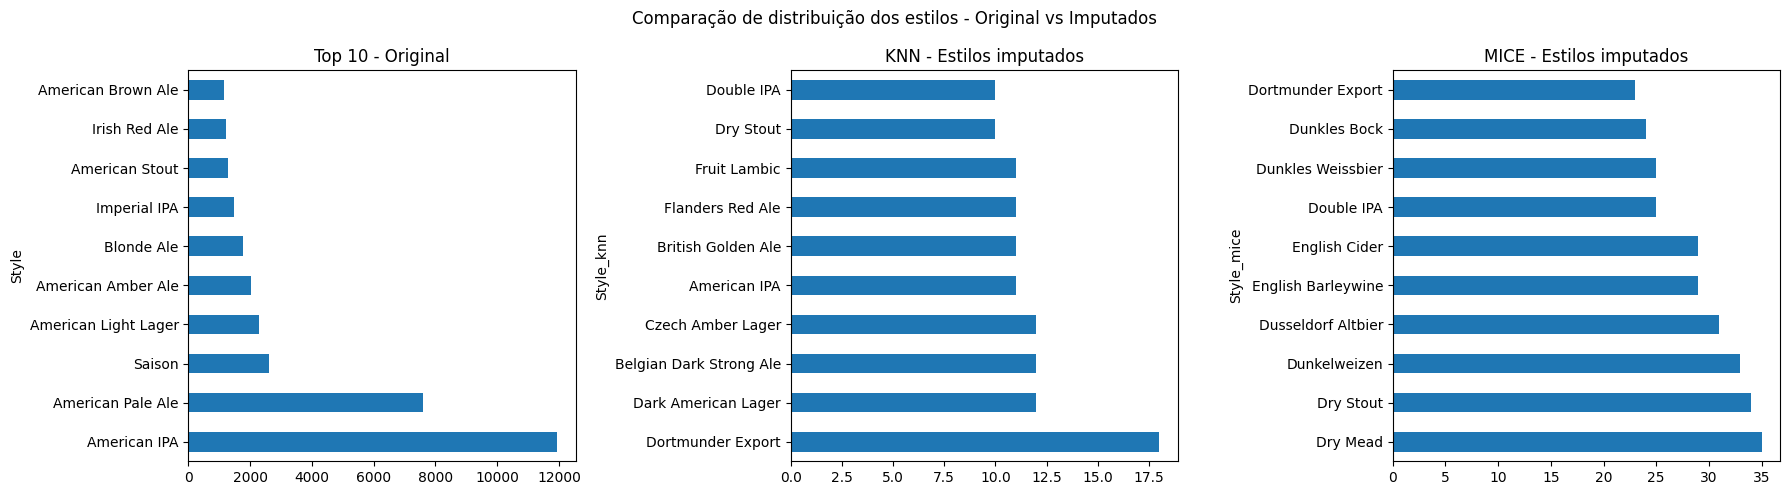

=== Estilos mais imputados - KNN ===
Style_knn
Dortmunder Export          18
Dark American Lager        12
Belgian Dark Strong Ale    12
Czech Amber Lager          12
American IPA               11
British Golden Ale         11
Flanders Red Ale           11
Fruit Lambic               11
Dry Stout                  10
Double IPA                 10
Name: count, dtype: int64

=== Estilos mais imputados - MICE ===
Style_mice
Dry Mead              35
Dry Stout             34
Dunkelweizen          33
Dusseldorf Altbier    31
English Barleywine    29
English Cider         29
Double IPA            25
Dunkles Weissbier     25
Dunkles Bock          24
Dortmunder Export     23
Name: count, dtype: int64


In [77]:
import matplotlib.pyplot as plt

# Top 10 estilos mais frequentes no original
top_styles = df['Style'].value_counts().head(10)

# Estilos imputados por cada método
knn_imputed = df_knn_cat.loc[missing_mask, 'Style_knn'].value_counts()
mice_imputed = df_mice_cat.loc[missing_mask, 'Style_mice'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparação de distribuição dos estilos - Original vs Imputados')

top_styles.plot(kind='barh', ax=axes[0], title='Top 10 - Original')
knn_imputed.head(10).plot(kind='barh', ax=axes[1], title='KNN - Estilos imputados')
mice_imputed.head(10).plot(kind='barh', ax=axes[2], title='MICE - Estilos imputados')

plt.tight_layout()
plt.show()

# Comparação numérica
print("=== Estilos mais imputados - KNN ===")
print(knn_imputed.head(10))
print("\n=== Estilos mais imputados - MICE ===")
print(mice_imputed.head(10))

###KNN:

Distribuição mais uniforme entre estilos — nenhum domina muito

Imputou American IPA (estilo mais frequente do dataset) entre os top 10 — indica sensibilidade à frequência

Contagens baixas (~10-18) sugerem maior diversidade nas imputações — cada cerveja encontrou vizinhos diferentes

###MICE:

Concentrou imputações em estilos começando com "D" (Dry Mead, Dunkelweizen, Dusseldorf...) — forte indício de viés do LabelEncoder, que ordena alfabeticamente, e o MICE tende a convergir para valores centrais do range numérico

Dry Mead sendo o mais imputado é suspeito — é um estilo incomum no dataset original, o que reforça o viés

Contagens maiores (~23-35) indicam menor diversidade — MICE convergiu para um conjunto menor de estilos

#Conclusão Variável Categórica:

🥇 KNN foi mais adequado para Style — produziu imputações mais diversas e com estilos que fazem sentido no contexto do dataset

❌ MICE apresentou viés claro do LabelEncoder — a codificação alfabética distorceu as imputações, concentrando em estilos com letras iniciais próximas ao centro do alfabeto

⚠️ Ambos os métodos são adaptações — nativamente não operam em categóricas. Para alta cardinalidade como Style, um classificador Random Forest ou CatBoost seria mais adequado na prática

# Comentários e Discussão Final

## 1. Interpretação dos Resultados

### Variável Numérica — PrimaryTemp
Todos os métodos zeraram os 22.662 valores faltantes (~30% do total) e
preservaram a média em torno de 19°C. As diferenças aparecem na
variabilidade (std) e nos valores extremos:

- **Função de Probabilidade** foi o método que mais fielmente preservou
  a distribuição original (std: 4.23 vs 4.22 original), mantendo quartis
  e limites praticamente idênticos ao dataset original.
- **Média do Grupo e KNN** produziram o mesmo std (3.71), comprimindo a
  variabilidade — efeito esperado em métodos baseados em médias.
- **MICE** gerou a maior suavização (std: 3.52), comprimindo também os
  quartis (Q1 subiu de 18.00 para 18.81).
- **Spline** foi o único a gerar valores impossíveis (min: -39°C,
  max: 120°C), tornando-o inadequado para esse dataset.

### Variável Categórica — Style
Ambos os métodos zeraram os 596 valores faltantes. As diferenças
aparecem na diversidade e coerência dos estilos imputados:

- **KNN** produziu imputações mais diversas e coerentes, com contagens
  uniformes (~10-18 por estilo) e presença do American IPA
  (estilo mais frequente do dataset).
- **MICE** concentrou imputações em estilos iniciados com "D"
  (Dry Mead, Dunkelweizen, Dusseldorf Altbier), revelando viés do
  LabelEncoder, que ordena categorias alfabeticamente e faz o MICE
  convergir para valores centrais do range numérico.

---

## 2. Comparação entre os Métodos

| Método | Preserva distribuição | Velocidade | Complexidade | Adequado para esse dataset |
|---|---|---|---|---|
| Média do Grupo | Parcial | ✅ Rápido | Baixa | ✅ Sim |
| Prob. Distribution | ✅ Melhor | ✅ Rápido | Baixa | ✅ Sim |
| Spline | ❌ Não | ✅ Rápido | Baixa | ❌ Não |
| KNN | Parcial | ⚠️ Lento | Média | ✅ Sim |
| MICE | Parcial | ❌ Muito lento | Alta | ⚠️ Parcial |

---

## 3. Dificuldades Encontradas

- **Spline**: método desenvolvido para séries temporais; no dataset
  sem ordenação lógica gerou valores fisicamente impossíveis de temperatura.
- **KNN e MICE para categóricas**: ambos operam nativamente apenas em
  variáveis numéricas, exigindo a adaptação via LabelEncoder
  (codificar → imputar → arredondar → decodificar), o que introduz
  limitações e vieses.
- **MICE com LabelEncoder**: a codificação alfabética do LabelEncoder
  distorceu as imputações do MICE, que convergiu para estilos no centro
  do range numérico — não necessariamente os mais frequentes ou adequados.
- **Escala do dataset**: com ~74k linhas, KNN e MICE demandaram tempo
  computacional significativo, especialmente o MICE com max_iter=10.

---

## 4. Percepção do Grupo sobre os Métodos mais Adequados

### Para variáveis numéricas contínuas:
- **Quando o objetivo é preservar a distribuição** → Função de
  Probabilidade é a melhor escolha, especialmente quando há muitos
  missings (>20%).
- **Quando há grupos com lógica clara** → Média do Grupo é simples,
  interpretável e eficaz.
- **Quando há correlação entre variáveis** → KNN é uma boa escolha,
  mas exige seleção cuidadosa das colunas preditoras.
- **Para análises estatísticas rigorosas** → MICE é o mais robusto
  teoricamente, mas o custo computacional e a necessidade de boas
  preditoras limitam seu uso prático.
- **Spline** → reservar apenas para séries temporais ou dados com
  ordenação lógica clara.

### Para variáveis categóricas de alta cardinalidade:
- **KNN** se mostrou mais adequado que MICE nesse contexto.
- Idealmente, para categóricas com muitos níveis como Style,
  recomenda-se métodos nativos de classificação como
  **Random Forest** ou **CatBoost**, que operam diretamente sobre
  categorias sem necessidade de codificação numérica.

### Consideração final:
Não existe método universalmente melhor — a escolha ideal depende
do tipo da variável, da proporção de missings, da relação entre
variáveis e do objetivo da análise. A combinação de métricas
estatísticas (média, std, quartis) com visualizações (KDE, boxplot)
é essencial para validar qualquer imputação antes de prosseguir
com a análise.